# Phase 1: Learned Gauge-Covariant Blocking ($\beta_f = 6.0$)

This notebook presents the Phase 1 learned blocking pipeline for 2D compact U(1) lattice gauge theory.

**Key ideas:**
- Enumerate a family of 7 gauge-covariant paths per coarse link direction (straight + 6 detour paths)
- Use a convolutional neural network to predict per-site combination weights from gauge-invariant features
- Jointly learn the blocking weights and a local coarse action (plaquette + rectangle basis)
- Loss: contrastive + MMD + mean mismatch, comparing blocked-fine vs model-sampled coarse ensembles

**Parameters:**
- Fine lattice: $L = 32$, $\beta_f = 6.0$, 1000 configurations
- Coarse lattice: $L = 16$, $\beta_c^{\text{tree}} = 1.5$

**Sections:**
1. Setup and fine-lattice sampling
2. Baseline: fixed (straight-path) blocker
3. Training the spatial NN blocker
4. Training curves
5. Per-observable distribution metrics
6. Distribution comparison (fixed vs learned)
7. Distribution consistency table
8. Path family visualization
9. Summary

In [1]:
import pickle
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from inverserg.actions import LocalWilsonLoopAction
from inverserg.baselines import tree_level_coarse_beta
from inverserg.blocking import (
    FixedGaugeCovariantBlocker,
    SpatialGaugeCovariantBlocker,
    _x_paths,
    _y_paths,
)
from inverserg.diagnostics import analyze_distribution_consistency
from inverserg.hmc import HMCU1Sampler
from inverserg.measurements import measurement_samples, plaquette_theory
from inverserg.training import (
    RGTrainingConfig,
    RGTrainingResult,
    generate_fine_ensemble,
    train_learned_rg,
)

torch.manual_seed(42)

FINE_L = 32
FINE_BETA = 6.0
COARSE_L = FINE_L // 2
COARSE_BETA = tree_level_coarse_beta(FINE_BETA)
N_CONFIGS = 1000
N_TEST = 200
EPOCHS = 40

CACHE_DIR = Path("../artifacts/cache_phase1_beta60")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Fine: L={FINE_L}, beta={FINE_BETA}")
print(f"Coarse: L={COARSE_L}, beta_tree={COARSE_BETA}")
print(f"Configs: {N_CONFIGS}, Test configs: {N_TEST}")
print(f"Epochs: {EPOCHS}")

Fine: L=32, beta=6.0
Coarse: L=16, beta_tree=1.5
Configs: 1000, Test configs: 200
Epochs: 40


---
## 1. Generate Fine Ensemble

Sample fine-lattice configurations via HMC with the Wilson plaquette action at $\beta_f = 6.0$ on a $32 \times 32$ lattice.

In [2]:
config = RGTrainingConfig(
    fine_lattice_size=FINE_L,
    fine_beta=FINE_BETA,
    coarse_beta_init=COARSE_BETA,
    n_fine_samples=N_CONFIGS,
    n_model_samples=256,
    n_test_samples=N_TEST,
    sampler_burn_in=100,
    sampler_thin=4,
    hmc_steps=10,
    hmc_step_size=0.08,
    epochs=EPOCHS,
    learning_rate=3e-2,
    blocker_type="spatial",
    spatial_hidden_dim=32,
    spatial_kernel_size=3,
    seed=42,
)

cache_path = CACHE_DIR / f"fine_L{FINE_L}_beta{FINE_BETA}_n{N_CONFIGS}.pt"
if cache_path.exists():
    fine_configs = torch.load(cache_path, weights_only=True)
    print(f"Loaded fine configs from cache: {fine_configs.shape}")
else:
    fine_configs = generate_fine_ensemble(config)
    torch.save(fine_configs, cache_path)
    print(f"Generated and cached fine configs: {fine_configs.shape}")

print(f"Mean plaquette: {torch.cos(fine_configs).mean():.4f}")
print(f"Theory (exact): {plaquette_theory(FINE_BETA):.4f}")

Loaded fine configs from cache: torch.Size([1000, 2, 32, 32])
Mean plaquette: -0.0005
Theory (exact): 0.9124


---
## 2. Baseline: Fixed Blocker

The fixed blocker uses only the straight path (equivalent to Phase 0 naive blocking). We compare blocked-fine observables against an independent coarse HMC at $\beta_c = 1.5$.

In [3]:
MEASUREMENT_NAMES = ("plaquette", "rectangle_x", "rectangle_y", "wilson_2x2", "topological_charge")

fixed_blocker = FixedGaugeCovariantBlocker()
with torch.no_grad():
    blocked_fixed = fixed_blocker(fine_configs)
print(f"Blocked-fixed shape: {blocked_fixed.shape}")

coarse_action = LocalWilsonLoopAction.wilson(COARSE_BETA)
coarse_sampler = HMCU1Sampler(
    lattice_size=COARSE_L, action=coarse_action,
    n_steps=config.hmc_steps, step_size=config.hmc_step_size,
)
coarse_baseline, acc_rate, _ = coarse_sampler.sample(
    n_samples=N_CONFIGS, burn_in=config.sampler_burn_in, thin=config.sampler_thin,
)
print(f"Coarse HMC acceptance: {acc_rate:.3f}")

diagnostics_baseline, samples_baseline = analyze_distribution_consistency(
    blocked_fixed, coarse_baseline, measurement_names=MEASUREMENT_NAMES,
)

header = "| Measurement | Blocked Mean | Coarse Mean | KS Stat | Verdict |"
sep = "|---|---:|---:|---:|---|"
rows = [header, sep]
for d in diagnostics_baseline:
    v = "consistent" if d.consistent else "**mismatch**"
    rows.append(f"| {d.measurement} | {d.blocked_mean:.4f} | {d.coarse_mean:.4f} | {d.ks_statistic:.4f} | {v} |")
display(Markdown("### Baseline Diagnostics\n\n" + "\n".join(rows)))

Blocked-fixed shape: torch.Size([1000, 2, 16, 16])


/home/genie/git/InverseRG/.venv/lib/python3.11/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Coarse HMC acceptance: 0.997


### Baseline Diagnostics

| Measurement | Blocked Mean | Coarse Mean | KS Stat | Verdict |
|---|---:|---:|---:|---|
| plaquette | 0.6945 | 0.5966 | 0.9380 | **mismatch** |
| rectangle_x | 0.4846 | 0.3546 | 0.8710 | **mismatch** |
| rectangle_y | 0.4820 | 0.3562 | 0.8440 | **mismatch** |
| wilson_2x2 | 0.2346 | 0.1242 | 0.7010 | **mismatch** |
| topological_charge | 0.2440 | -0.0510 | 0.2840 | **mismatch** |

---
## 3. Train Spatial NN Blocker

The `SpatialGaugeCovariantBlocker` uses a small CNN (12 gauge-invariant features → 7 path logits per direction per site) to learn spatially-varying path combination weights. We jointly optimize the blocker and a generalized coarse action (plaquette + rectangle basis).

In [4]:
result_cache = CACHE_DIR / f"result_spatial_L{FINE_L}_beta{FINE_BETA}_e{EPOCHS}.pkl"
blocker_cache = CACHE_DIR / f"blocker_spatial_L{FINE_L}_beta{FINE_BETA}_e{EPOCHS}.pt"

learned_blocker = SpatialGaugeCovariantBlocker(
    hidden_dim=config.spatial_hidden_dim,
    kernel_size=config.spatial_kernel_size,
)

if result_cache.exists() and blocker_cache.exists():
    with open(result_cache, "rb") as f:
        result = pickle.load(f)
    learned_blocker.load_state_dict(torch.load(blocker_cache, weights_only=True))
    print("Loaded training result and blocker from cache.")
else:
    result = train_learned_rg(fine_configs=fine_configs, config=config, blocker=learned_blocker)
    with open(result_cache, "wb") as f:
        pickle.dump(result, f)
    torch.save(learned_blocker.state_dict(), blocker_cache)
    print("Training complete.")

print(f"Baseline MMD: {result.baseline_mismatch:.6f}")
print(f"Final MMD:    {result.final_mismatch:.6f}")
print(f"Blocker: {result.blocker_summary}")
print(f"Learned action coefficients: {result.learned_action_coefficients}")

Loaded training result and blocker from cache.
Baseline MMD: 0.159687
Final MMD:    0.111605
Blocker: {'type': 'SpatialGaugeCovariantBlocker', 'n_parameters': 5006, 'n_paths': 7, 'hidden_dim': 32, 'kernel_size': 3}
Learned action coefficients: {'plaquette': 2.040189743041992, 'rectangle_x': 0.12075721472501755, 'rectangle_y': 0.10132689028978348}


---
## 4. Training Curves

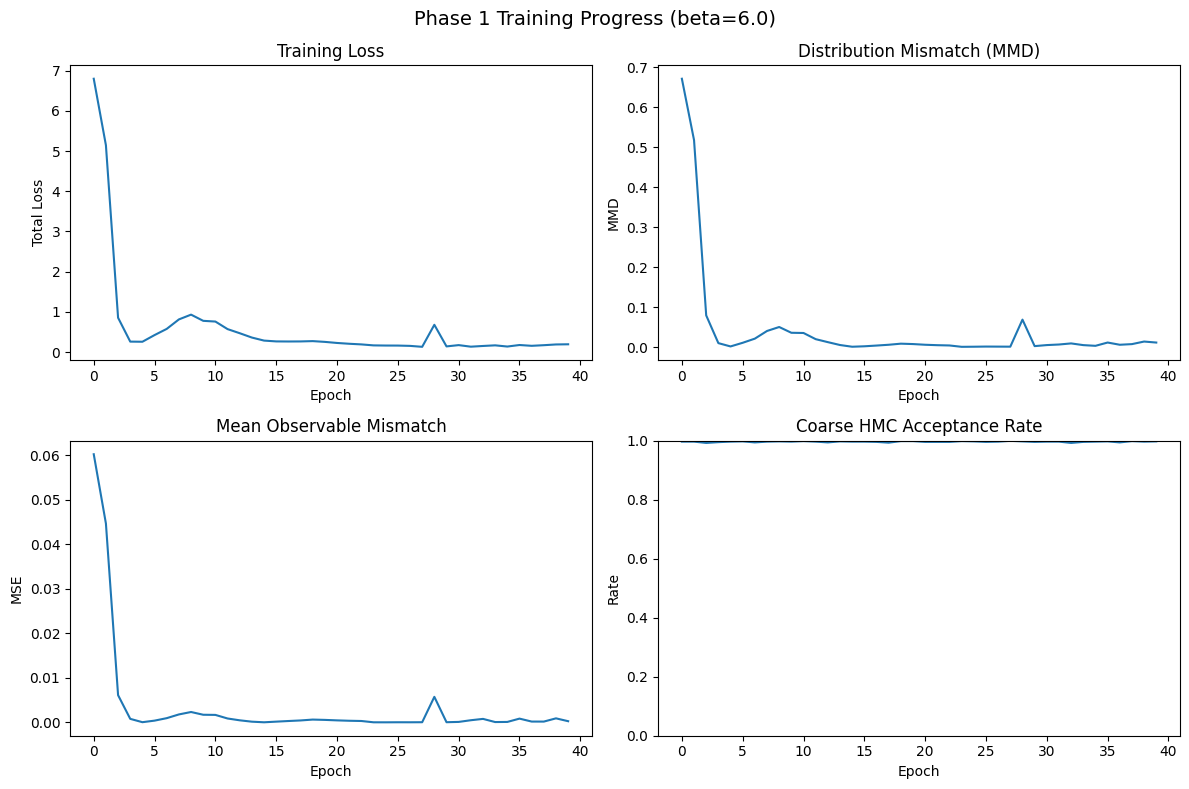

In [5]:
history = result.history
epochs_arr = [h["epoch"] for h in history]
losses = [h["loss"] for h in history]
dist_mm = [h["distribution_mismatch"] for h in history]
mean_mm = [h["mean_mismatch"] for h in history]
acc_rates = [h["acceptance_rate"] for h in history]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(epochs_arr, losses)
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Total Loss")
axes[0, 0].set_title("Training Loss")

axes[0, 1].plot(epochs_arr, dist_mm)
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("MMD")
axes[0, 1].set_title("Distribution Mismatch (MMD)")

axes[1, 0].plot(epochs_arr, mean_mm)
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("MSE")
axes[1, 0].set_title("Mean Observable Mismatch")

axes[1, 1].plot(epochs_arr, acc_rates)
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Rate")
axes[1, 1].set_title("Coarse HMC Acceptance Rate")
axes[1, 1].set_ylim(0, 1)

fig.suptitle(f"Phase 1 Training Progress (beta={FINE_BETA})", fontsize=14)
fig.tight_layout()
plt.show()

---
## 5. Per-Observable Distribution Metrics

Compare per-observable MMD, energy distance, and mean/std between blocked-fine and model ensembles.

In [6]:
header = "| Observable | MMD | Energy Dist | Blocked Mean | Model Mean | Blocked Std | Model Std |"
sep = "|---|---:|---:|---:|---:|---:|---:|"
rows = ["### Train-Set Distribution Metrics", "", header, sep]
for name, m in result.final_distribution_metrics.items():
    rows.append(
        f"| {name} | {m['mmd']:.6f} | {m['energy_distance']:.6f} | "
        f"{m['blocked_mean']:.4f} | {m['model_mean']:.4f} | "
        f"{m['blocked_std']:.4f} | {m['model_std']:.4f} |"
    )

if result.test_distribution_metrics:
    rows.extend(["", "### Test-Set Distribution Metrics", "", header, sep])
    for name, m in result.test_distribution_metrics.items():
        rows.append(
            f"| {name} | {m['mmd']:.6f} | {m['energy_distance']:.6f} | "
            f"{m['blocked_mean']:.4f} | {m['model_mean']:.4f} | "
            f"{m['blocked_std']:.4f} | {m['model_std']:.4f} |"
        )

display(Markdown("\n".join(rows)))

### Train-Set Distribution Metrics

| Observable | MMD | Energy Dist | Blocked Mean | Model Mean | Blocked Std | Model Std |
|---|---:|---:|---:|---:|---:|---:|
| plaquette | 0.004694 | 0.028552 | 0.7850 | 0.7506 | 0.0176 | 0.0237 |
| rectangle_x | 0.000182 | 0.000738 | 0.5838 | 0.5770 | 0.0369 | 0.0393 |
| rectangle_y | 0.000068 | 0.000321 | 0.5810 | 0.5768 | 0.0385 | 0.0388 |
| wilson_2x2 | 0.007879 | 0.020614 | 0.3018 | 0.3471 | 0.0583 | 0.0528 |
| topological_charge | 0.110858 | 0.228488 | 0.2410 | 0.0195 | 0.8518 | 1.8374 |

### Test-Set Distribution Metrics

| Observable | MMD | Energy Dist | Blocked Mean | Model Mean | Blocked Std | Model Std |
|---|---:|---:|---:|---:|---:|---:|
| plaquette | 0.005019 | 0.032477 | 0.7861 | 0.7506 | 0.0169 | 0.0218 |
| rectangle_x | 0.000056 | 0.000311 | 0.5819 | 0.5782 | 0.0355 | 0.0384 |
| rectangle_y | 0.000216 | 0.001065 | 0.5844 | 0.5770 | 0.0361 | 0.0365 |
| wilson_2x2 | 0.008129 | 0.020433 | 0.3027 | 0.3487 | 0.0574 | 0.0510 |
| topological_charge | 0.342019 | 1.338329 | -1.4450 | 0.1055 | 0.5644 | 1.9804 |

---
## 6. Distribution Comparison: Fixed vs Learned MCRG

Both columns compare the MCRG-blocked fine ensemble against the coarse-action HMC ensemble.
- **Left**: fixed (straight-path) blocker + tree-level coarse action
- **Right**: learned (spatial NN) blocker + jointly learned coarse action

Blocked-learned shape: torch.Size([1000, 2, 16, 16])
Learned coarse HMC acceptance: 0.996


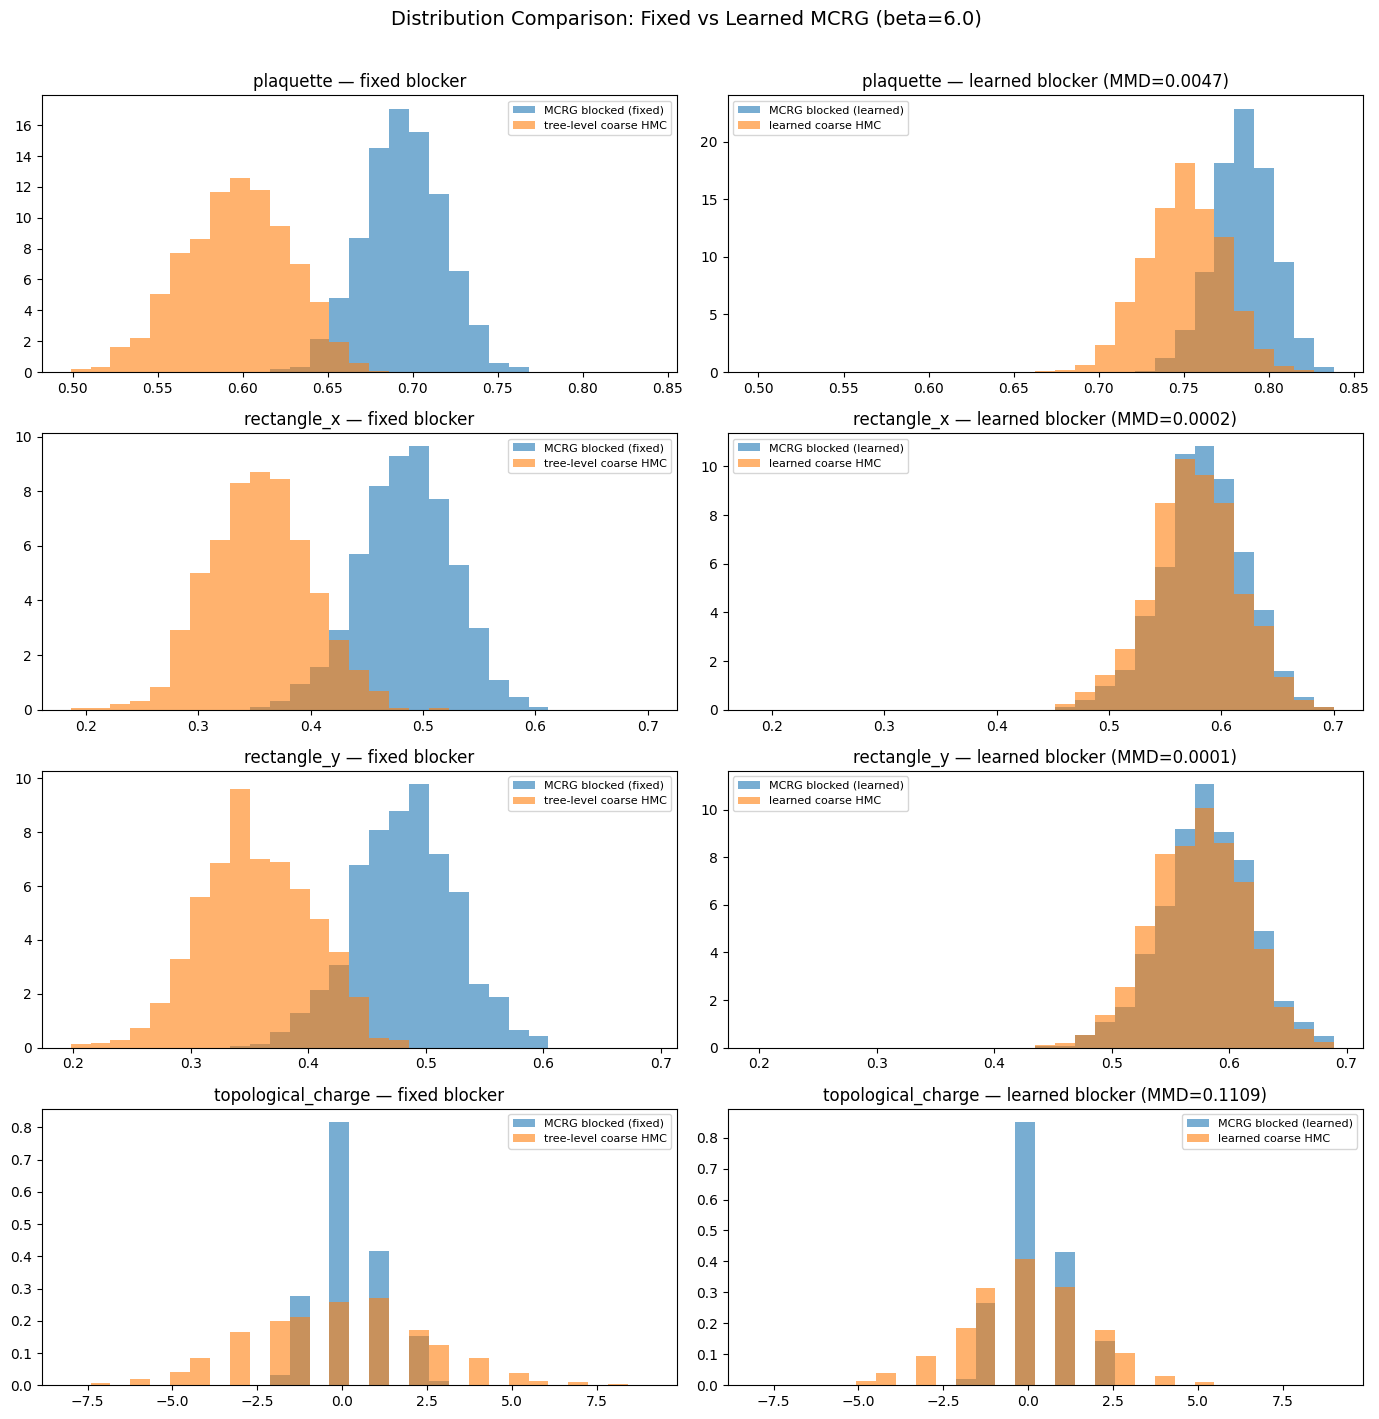

In [7]:
with torch.no_grad():
    blocked_learned = learned_blocker(fine_configs)
print(f"Blocked-learned shape: {blocked_learned.shape}")

learned_action = LocalWilsonLoopAction(
    basis=config.basis,
    initial_coefficients=torch.tensor([result.learned_action_coefficients[b] for b in config.basis]),
)
coarse_learned_sampler = HMCU1Sampler(
    lattice_size=COARSE_L, action=learned_action,
    n_steps=config.hmc_steps, step_size=config.hmc_step_size,
)
coarse_learned, acc_learned, _ = coarse_learned_sampler.sample(
    n_samples=N_CONFIGS, burn_in=config.sampler_burn_in, thin=config.sampler_thin,
)
print(f"Learned coarse HMC acceptance: {acc_learned:.3f}")

plot_measurements = ("plaquette", "rectangle_x", "rectangle_y", "topological_charge")
blocked_fixed_samples = measurement_samples(blocked_fixed, plot_measurements)
coarse_baseline_samples = measurement_samples(coarse_baseline, plot_measurements)
blocked_learned_samples = measurement_samples(blocked_learned, plot_measurements)
coarse_learned_samples = measurement_samples(coarse_learned, plot_measurements)

fig, axes = plt.subplots(len(plot_measurements), 2, figsize=(14, 3.5 * len(plot_measurements)))
fig.suptitle(f"Distribution Comparison: Fixed vs Learned MCRG (beta={FINE_BETA})", fontsize=14, y=1.01)

for row_idx, mname in enumerate(plot_measurements):
    ax_fixed = axes[row_idx, 0]
    ax_learned = axes[row_idx, 1]

    all_vals = np.concatenate([
        blocked_fixed_samples[mname].numpy(),
        coarse_baseline_samples[mname].numpy(),
        blocked_learned_samples[mname].numpy(),
        coarse_learned_samples[mname].numpy(),
    ])
    bins = np.linspace(all_vals.min(), all_vals.max(), 30)

    ax_fixed.hist(blocked_fixed_samples[mname].numpy(), bins=bins, alpha=0.6, density=True,
                  label="MCRG blocked (fixed)")
    ax_fixed.hist(coarse_baseline_samples[mname].numpy(), bins=bins, alpha=0.6, density=True,
                  label="tree-level coarse HMC")
    ax_fixed.set_title(f"{mname} \u2014 fixed blocker")
    ax_fixed.legend(fontsize=8)

    ax_learned.hist(blocked_learned_samples[mname].numpy(), bins=bins, alpha=0.6, density=True,
                    label="MCRG blocked (learned)")
    ax_learned.hist(coarse_learned_samples[mname].numpy(), bins=bins, alpha=0.6, density=True,
                    label="learned coarse HMC")
    if mname in result.final_distribution_metrics:
        m = result.final_distribution_metrics[mname]
        ax_learned.set_title(f"{mname} \u2014 learned blocker (MMD={m['mmd']:.4f})")
    else:
        ax_learned.set_title(f"{mname} \u2014 learned blocker")
    ax_learned.legend(fontsize=8)

fig.tight_layout()
plt.show()

In [8]:
diagnostics_learned, _ = analyze_distribution_consistency(
    blocked_learned, coarse_learned, measurement_names=MEASUREMENT_NAMES,
)

rows = [
    "### Fixed vs Learned MCRG: Distribution Consistency",
    "",
    "| Observable | Fixed KS | Fixed Δmean | Fixed | Learned KS | Learned Δmean | Learned |",
    "|---|---:|---:|:---:|---:|---:|:---:|",
]
n_fixed_pass = 0
n_learned_pass = 0
for df, dl in zip(diagnostics_baseline, diagnostics_learned):
    vf = "\u2713" if df.consistent else "\u2717"
    vl = "\u2713" if dl.consistent else "\u2717"
    n_fixed_pass += df.consistent
    n_learned_pass += dl.consistent
    delta_f = abs(df.blocked_mean - df.coarse_mean)
    delta_l = abs(dl.blocked_mean - dl.coarse_mean)
    rows.append(
        f"| {df.measurement} "
        f"| {df.ks_statistic:.4f} | {delta_f:.4f} | {vf} "
        f"| {dl.ks_statistic:.4f} | {delta_l:.4f} | {vl} |"
    )

rows.extend([
    "",
    f"**KS test pass rate**: Fixed {n_fixed_pass}/{len(diagnostics_baseline)}, "
    f"Learned {n_learned_pass}/{len(diagnostics_learned)}",
    "",
    f"(KS critical value at \u03b1=0.05: {diagnostics_baseline[0].ks_critical_value:.4f} "
    f"for N={N_CONFIGS}+{N_CONFIGS} samples)",
])

display(Markdown("\n".join(rows)))

### Fixed vs Learned MCRG: Distribution Consistency

| Observable | Fixed KS | Fixed Δmean | Fixed | Learned KS | Learned Δmean | Learned |
|---|---:|---:|:---:|---:|---:|:---:|
| plaquette | 0.9380 | 0.0979 | ✗ | 0.6140 | 0.0348 | ✗ |
| rectangle_x | 0.8710 | 0.1301 | ✗ | 0.0980 | 0.0073 | ✗ |
| rectangle_y | 0.8440 | 0.1258 | ✗ | 0.0870 | 0.0061 | ✗ |
| wilson_2x2 | 0.7010 | 0.1104 | ✗ | 0.3300 | 0.0444 | ✗ |
| topological_charge | 0.2840 | 0.2950 | ✗ | 0.2160 | 0.2650 | ✗ |

**KS test pass rate**: Fixed 0/5, Learned 0/5

(KS critical value at α=0.05: 0.0608 for N=1000+1000 samples)

---
## 7. Path Family Visualization

The 7 paths per coarse-link direction used in the blocking:

In [9]:
path_names_x = ["straight", "up", "down", "staircase_up", "staircase_dn", "mid_up", "mid_down"]
path_names_y = ["straight", "right", "left", "staircase_rt", "staircase_lt", "mid_right", "mid_left"]

with torch.no_grad():
    sample_field = fine_configs[:1]
    xp = _x_paths(sample_field)
    yp = _y_paths(sample_field)

print(f"X-paths shape: {xp.shape}  (batch, n_paths, L_c, L_c)")
print(f"Y-paths shape: {yp.shape}")
print()

path_descs = [
    ("straight", "x, x", 2),
    ("up", "y, x, x, -y", 4),
    ("down", "-y, x, x, y", 4),
    ("staircase_up", "y, x, -y, x", 4),
    ("staircase_dn", "-y, x, y, x", 4),
    ("mid_up", "x, y, x, -y", 4),
    ("mid_down", "x, -y, x, y", 4),
]
header = "| Index | Name | Steps | N Links |"
sep = "|---:|---|---|---:|"
rows = ["### Path descriptions (x-direction)", "", header, sep]
for i, (name, steps, n) in enumerate(path_descs):
    rows.append(f"| {i} | {name} | {steps} | {n} |")
display(Markdown("\n".join(rows)))

X-paths shape: torch.Size([1, 7, 16, 16])  (batch, n_paths, L_c, L_c)
Y-paths shape: torch.Size([1, 7, 16, 16])



### Path descriptions (x-direction)

| Index | Name | Steps | N Links |
|---:|---|---|---:|
| 0 | straight | x, x | 2 |
| 1 | up | y, x, x, -y | 4 |
| 2 | down | -y, x, x, y | 4 |
| 3 | staircase_up | y, x, -y, x | 4 |
| 4 | staircase_dn | -y, x, y, x | 4 |
| 5 | mid_up | x, y, x, -y | 4 |
| 6 | mid_down | x, -y, x, y | 4 |

---
## 8. Summary

Comparison of Phase 0 (fixed straight-path blocker) against Phase 1 (learned spatial NN blocker).

In [10]:
rows = [
    "### Phase 0 vs Phase 1 Summary",
    "",
    "| | Phase 0 (Fixed) | Phase 1 (Learned) |",
    "|---|---|---|",
    f"| Blocker | Straight path only | Spatial NN, {result.blocker_summary.get('n_paths', '?')} paths |",
    f"| Blocker parameters | 0 | {result.blocker_summary.get('n_parameters', '?')} |",
    f"| Learned action coefficients | beta_c = {COARSE_BETA} | {result.learned_action_coefficients} |",
    f"| Eval MMD (train) | {result.baseline_mismatch:.6f} | {result.final_mismatch:.6f} |",
]
if result.test_distribution_metrics:
    test_mmds = [m["mmd"] for m in result.test_distribution_metrics.values()]
    rows.append(f"| Mean test MMD | -- | {np.mean(test_mmds):.6f} |")

display(Markdown("\n".join(rows)))

if result.final_mismatch < result.baseline_mismatch:
    improvement = (1 - result.final_mismatch / max(result.baseline_mismatch, 1e-12)) * 100
    print(f"\nLearned blocker reduces train MMD by {improvement:.1f}% relative to baseline.")
else:
    print("\nLearned blocker did not improve over baseline on this run.")

### Phase 0 vs Phase 1 Summary

| | Phase 0 (Fixed) | Phase 1 (Learned) |
|---|---|---|
| Blocker | Straight path only | Spatial NN, 7 paths |
| Blocker parameters | 0 | 5006 |
| Learned action coefficients | beta_c = 1.5 | {'plaquette': 2.040189743041992, 'rectangle_x': 0.12075721472501755, 'rectangle_y': 0.10132689028978348} |
| Eval MMD (train) | 0.159687 | 0.111605 |
| Mean test MMD | -- | 0.071088 |


Learned blocker reduces train MMD by 30.1% relative to baseline.
